In [3]:
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.font_manager import FontProperties
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib as mpl
from pathlib import Path
import sys

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

In [4]:
# Configuration
config = {
    'observed_data_bow': project_root / 'data' / 'input_data' / 'for_visualization' / 'bow_combined_swe_data.csv',
    'casr_input_data': project_root / 'data' / 'input_data' / 'for_visualization' / 'bow_casrv3.2_SWE_P_data.csv',
    'original_bow_canswe_data' : project_root / 'data' / 'input_data' / 'for_visualization'/'bow_canswe_selected_final.nc',
    'gap_filled_bow_canswe_data' : project_root / 'data' / 'input_data' / 'for_visualization'/'bow_swe_gapfilled_data_final.nc',
    'SWEI_data' : project_root / 'data' / 'input_data' / 'for_visualization'/'bow_casr_swei_8mo_new.csv',
    'SWEI_canswe': project_root / 'data' / 'input_data' / 'for_visualization'/'swei_comparison.csv',
    'weekly_SWEI': project_root / 'data' / 'input_data' / 'for_visualization'/'bow_weekly_swei.csv',
    'SD_classification_all_years': project_root / 'data' / 'input_data' / 'for_visualization'/'Snow_Drought_Classification_All_Years.csv',
    'SD_types': project_root / 'data' / 'input_data' / 'for_visualization'/'Snow_Drought_Years_by_Type_clean.csv',
    'drought_years': project_root / 'data' / 'input_data' / 'for_visualization'/'Drought_Years_by_Elevation.csv',
    'SPI_data': project_root / 'data' / 'input_data' / 'for_visualization'/'bow_casr_spi_8mo.csv',
    'peak_swe_data': project_root / 'data' / 'input_data' / 'for_visualization'/'peak_swe_data.csv',
    'shapefile': project_root / 'data' / 'input_data' / 'shapefiles'/'BowRiverBasin'/'Bow_elevation_combined.shp',
    'output_plots': project_root / 'data' / 'output_plots' / 'for_paper'/'Final',
    'output_data': project_root / 'data' / 'output_data' / 'for_paper'/'Final'
}

In [5]:


# load shapefile
shapefile_path = config['shapefile']
shapefile = gpd.read_file(shapefile_path)

# load observed data
observed_data_path = config['observed_data_bow']
observed_data = pd.read_csv(observed_data_path)

# load CASR data
casr_data_path = config['casr_input_data']
casr_data = pd.read_csv(casr_data_path)

# load original CANSWE data
original_canswe_data_path = config['original_bow_canswe_data']
original_canswe_data = xr.open_dataset(original_canswe_data_path)

# load gap-filled CANSWE data
gap_filled_canswe_data_path = config['gap_filled_bow_canswe_data']
gap_filled_canswe_data = xr.open_dataset(gap_filled_canswe_data_path)

# Data co-ordinates

C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_38072\2675792471.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=12, family="Times New Roman", fontweight="bold")
C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_38072\2675792471.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=12, family="Times New Roman", fontweight="bold")


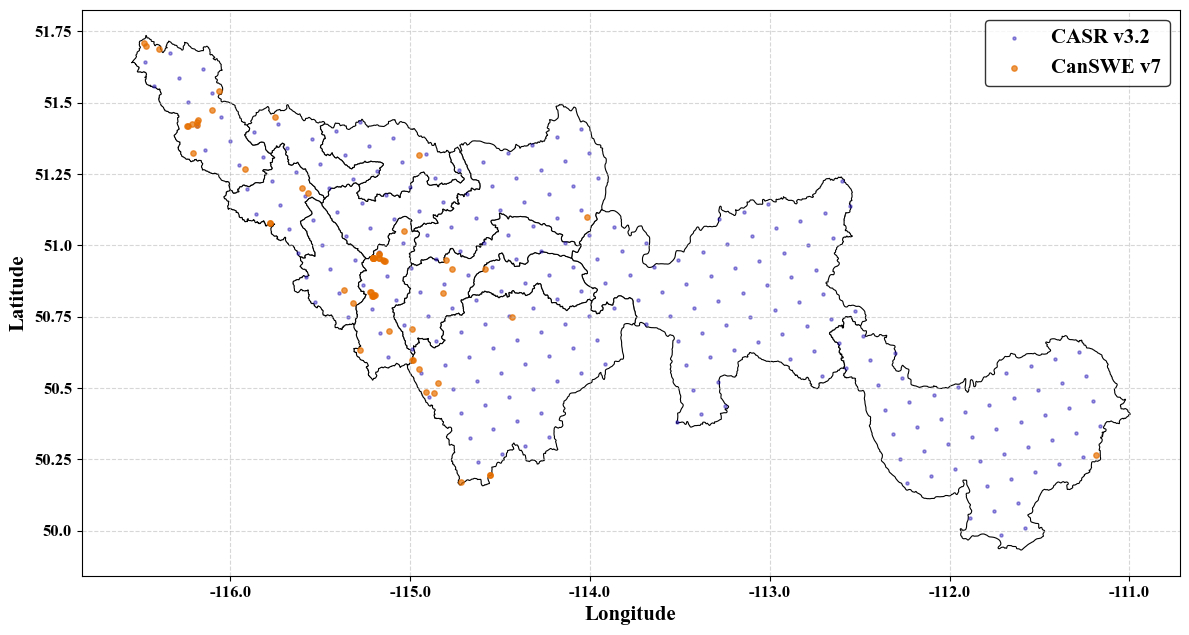

In [31]:
# Prepare unique point locations
obs_points = observed_data[['lon', 'lat']].dropna().drop_duplicates()
casr_points = casr_data[['lon', 'lat']].dropna().drop_duplicates()

gap_points = (
    gap_filled_canswe_data[['lat', 'lon']]
    .to_dataframe()
    .reset_index()
    [['lon', 'lat']]
    .dropna()
    .drop_duplicates()
)

# Convert to GeoDataFrames
obs_gdf = gpd.GeoDataFrame(
    obs_points,
    geometry=gpd.points_from_xy(obs_points['lon'], obs_points['lat']),
    crs="EPSG:4326",
)

casr_gdf = gpd.GeoDataFrame(
    casr_points,
    geometry=gpd.points_from_xy(casr_points['lon'], casr_points['lat']),
    crs="EPSG:4326",
)

gap_gdf = gpd.GeoDataFrame(
    gap_points,
    geometry=gpd.points_from_xy(gap_points['lon'], gap_points['lat']),
    crs="EPSG:4326",
)

# Reproject to shapefile CRS if needed
target_crs = shapefile.crs if shapefile.crs is not None else "EPSG:4326"
if obs_gdf.crs != target_crs:
    obs_gdf = obs_gdf.to_crs(target_crs)
if casr_gdf.crs != target_crs:
    casr_gdf = casr_gdf.to_crs(target_crs)
if gap_gdf.crs != target_crs:
    gap_gdf = gap_gdf.to_crs(target_crs)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

shapefile.plot(ax=ax, color="white", edgecolor="black", linewidth=0.8)
casr_gdf.plot(ax=ax, color="#1200B2", markersize=5, alpha=0.4, label="CASR v3.2")
gap_gdf.plot(ax=ax, color="#E66F00", markersize=15, alpha=0.7, label="CanSWE v7")
#obs_gdf.plot(ax=ax, color="#E66F00", markersize=15, alpha=0.7, label="Observed")

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel("Longitude",fontsize=15, family="Times New Roman", fontweight="bold")
ax.set_ylabel("Latitude",fontsize=15, family="Times New Roman", fontweight="bold")
ax.set_xticklabels(ax.get_xticks(), fontsize=12, family="Times New Roman", fontweight="bold")
ax.set_yticklabels(ax.get_yticks(), fontsize=12, family="Times New Roman", fontweight="bold")
ax.legend(prop={"size": 15, "family": "Times New Roman", "weight": "bold"}, loc="upper right", frameon=True, facecolor="white", edgecolor="black")
save_path = config['output_plots'] / 'bow_canswe_data_points_map.png'
plt.savefig(save_path, dpi=1000)
plt.tight_layout()
plt.show()

# SWEI and SD classification

In [7]:
# load SWEI data
swei_data_path = config['SWEI_data']
swei_data = pd.read_csv(swei_data_path)
display(swei_data.head())

# load canswe SWEI comparison data
swei_canswe_data_path = config['SWEI_canswe']
swei_canswe_data = pd.read_csv(swei_canswe_data_path)
display(swei_canswe_data.head())

# load SPI data
spi_data_path = config['SPI_data']
spi_data = pd.read_csv(spi_data_path)
display(spi_data.head())

# load SD classification data
sd_classification_path = config['SD_classification_all_years']
sd_classification_data = pd.read_csv(sd_classification_path)
display(sd_classification_data.head())

sd_types_path = config['SD_types']
sd_types_data = pd.read_csv(sd_types_path)
display(sd_types_data.head())

,index,station_id,time,SWE_monthly,Seasonal_Year,SWE_8mo,month,Gringorten_p,SWEI,lon,lat,Elevation_Category
0,0,1,1981-05-01,5072.800764,1980,30306.975814,5,0.556664,0.142516,-116.138,51.3346,2000_2500m
1,1,1,1982-05-01,7276.954120,1981,34493.079364,5,0.737987,0.637153,-116.138,51.3346,2000_2500m
2,2,1,1983-05-01,5607.820307,1982,34208.649527,5,0.692656,0.503394,-116.138,51.3346,2000_2500m
3,3,1,1984-05-01,5777.537110,1983,28006.298830,5,0.420671,-0.200177,-116.138,51.3346,2000_2500m
4,4,1,1985-05-01,4583.076164,1984,26935.667961,5,0.352675,-0.378110,-116.138,51.3346,2000_2500m


,station_id,time,Seasonal_Year,Elevation_Category,Gap_filled_SWEI,Original_SWEI
0,ALE-05BA801,1981-05-01,1980,1500_2000m,0.948841,0.948841
1,ALE-05BA801,1982-05-01,1981,1500_2000m,0.258513,0.258513
2,ALE-05BA801,1983-05-01,1982,1500_2000m,0.085324,0.085324
3,ALE-05BA801,1984-05-01,1983,1500_2000m,-0.948841,-0.948841
4,ALE-05BA801,1985-05-01,1984,1500_2000m,-0.378110,-0.378110


,station_id,time,Precipitation_monthly,Seasonal_Year,Precipitation_8mo,SPI,lon,lat,Elevation_Category,month
0,1,1981-05-01,49.272601,1980,330.692535,-0.401809,-116.138,51.3346,2000_2500m,5
1,1,1982-05-01,24.854834,1981,321.687604,-0.531544,-116.138,51.3346,2000_2500m,5
2,1,1983-05-01,25.470663,1982,231.587842,-1.990738,-116.138,51.3346,2000_2500m,5
3,1,1984-05-01,67.581612,1983,272.967472,-1.279772,-116.138,51.3346,2000_2500m,5
4,1,1985-05-01,44.867321,1984,258.220625,-1.524064,-116.138,51.3346,2000_2500m,5


,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,is_swei_drought,cluster_name,cluster
0,1000_1500m,1980,0.017906,43.219919,True,Warm,0.0
1,1000_1500m,1981,0.043095,-27.761347,False,Normal,-1.0
2,1000_1500m,1982,0.027718,-41.996265,True,Warm & Dry,2.0
3,1000_1500m,1983,0.037195,-60.840708,False,Normal,-1.0
4,1000_1500m,1984,0.054673,-81.794527,False,Normal,-1.0


,Elevation_Category,dry,dry&warm,warm,Drought_Years,unmatched,missing_from_classification_data
0,500_1000m,"[2004, 2018]","[1997, 1998, 2000, 2015, 2016, 2021]","[1994, 2005, 2006, 2011, 2023]","[1994, 1997, 1998, 2000, 2004, 2005, 2006, 201...",[],[]
1,1000_1500m,"[1987, 2000]","[1982, 1991, 1993, 2004, 2005, 2015]","[1980, 1994, 1998, 2007, 2011]","[1980, 1982, 1987, 1991, 1993, 1994, 1998, 200...",[],[]
2,1500_2000m,"[1991, 1993, 2000, 2015]","[1998, 2004, 2005, 2006]","[1980, 1994, 2002, 2007, 2011]","[1980, 1991, 1993, 1994, 1998, 2000, 2002, 200...",[],[]
3,2000_2500m,"[1987, 2000, 2009]","[1996, 1998, 2004, 2005, 2015]","[1997, 2002, 2011]","[1987, 1996, 1997, 1998, 2000, 2002, 2004, 200...",[],[]


In [8]:
# avaerage CaSR SWEI over the Elevation categories, month and seasonal year
swei_8mo_avg = (
    swei_data
    .groupby(
        ['Elevation_Category', 'Seasonal_Year','month'],
        as_index=False
    )
    .agg(
        Avg_SWEI_8mo=('SWEI', 'mean')
    )
)

save_path = config['output_data'] / 'swei_8mo_avg.csv'
swei_8mo_avg.to_csv(save_path, index=False)
display(swei_8mo_avg.head())

,Elevation_Category,Seasonal_Year,month,Avg_SWEI_8mo
0,1000_1500m,1980,5,-0.778473
1,1000_1500m,1981,5,0.320094
2,1000_1500m,1982,5,-0.942805
3,1000_1500m,1983,5,-0.356098
4,1000_1500m,1984,5,-0.147442


In [9]:
# avaerage CanSWE SWEI over the Elevation categories, month and seasonal year
swei_canswe_data_avg = (
    swei_canswe_data
    .groupby(
        ['Elevation_Category', 'Seasonal_Year'],
        as_index=False
    )
    .agg(
        Avg_SWEI_gapfilled=('Gap_filled_SWEI', 'mean'), Avg_SWEI_original=('Original_SWEI', 'mean')
    )
)

save_path = config['output_data'] / 'swei_canswe_data_avg.csv'
swei_canswe_data_avg.to_csv(save_path, index=False)
display(swei_canswe_data_avg.head())

,Elevation_Category,Seasonal_Year,Avg_SWEI_gapfilled,Avg_SWEI_original
0,1000_1500m,1980,0.491228,0.518785
1,1000_1500m,1981,0.732935,0.732935
2,1000_1500m,1982,0.732935,0.215920
3,1000_1500m,1983,0.484559,0.538370
4,1000_1500m,1984,0.491228,0.651566


SWEI comparison

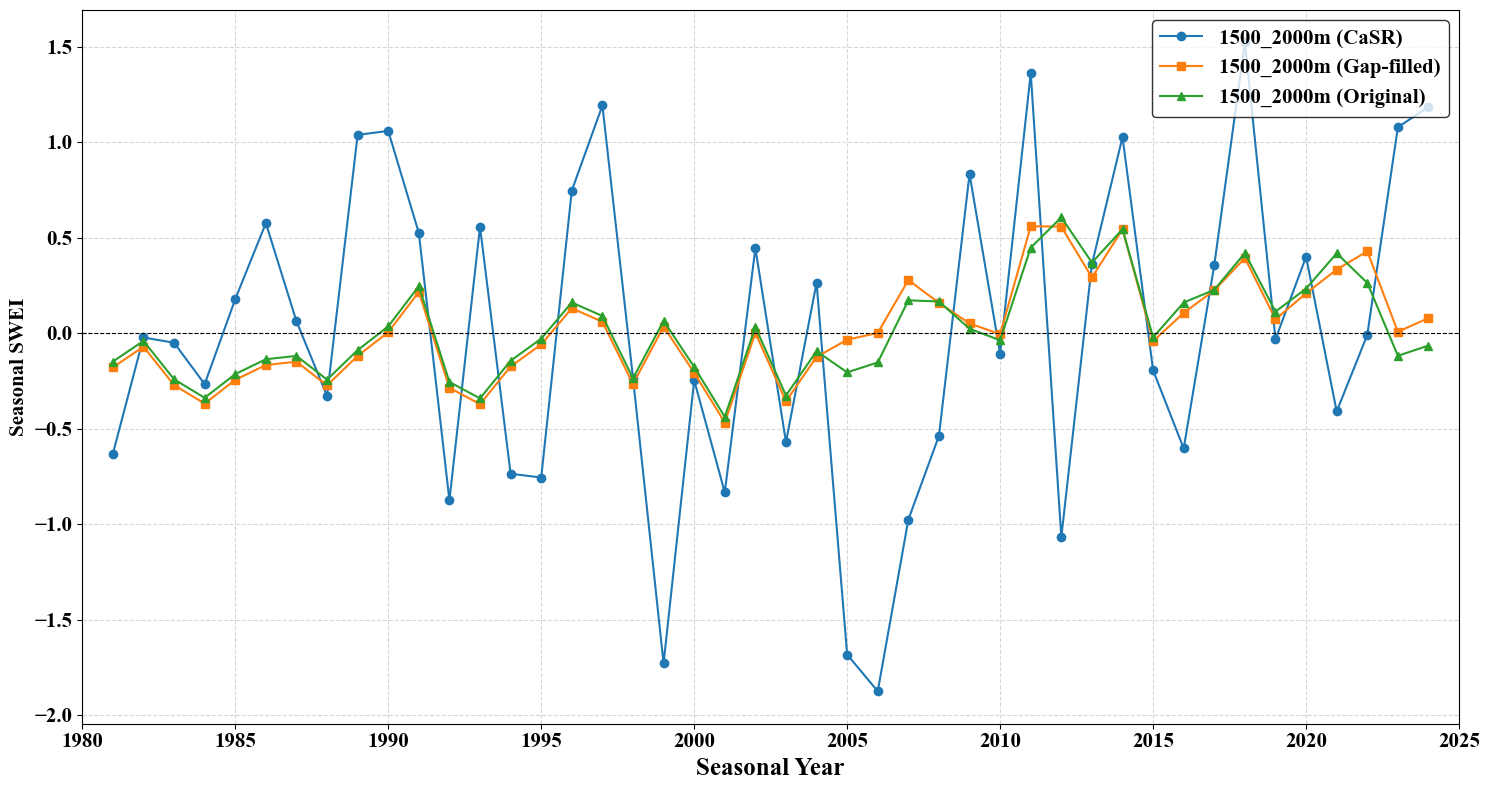

In [36]:
# plot time series of SWEI for each elevation category
# plot two elevations in subplots
elevs = ['1500_2000m', '2000_2500m']

fig, axs = plt.subplots(figsize=(15, 8), sharex=True)
axs = np.atleast_1d(axs)

for ax, elev in zip(axs, elevs):
    df1 = swei_8mo_avg[swei_8mo_avg['Elevation_Category'] == elev].sort_values('Seasonal_Year')
    df2 = swei_canswe_data_avg[swei_canswe_data_avg['Elevation_Category'] == elev].sort_values('Seasonal_Year')
    ax.plot(df1['Seasonal_Year'] + 1, df1['Avg_SWEI_8mo'], marker='o', linewidth=1.5, label=f'{elev} (CaSR)')
    ax.plot(df2['Seasonal_Year'] + 1, df2['Avg_SWEI_gapfilled'], marker='s', linewidth=1.5, label=f'{elev} (Gap-filled)')
    ax.plot(df2['Seasonal_Year'] + 1, df2['Avg_SWEI_original'], marker='^', linewidth=1.5, label=f'{elev} (Original)')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylabel('Seasonal SWEI', fontsize=15, family="Times New Roman", fontweight="bold")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(prop={'family': 'Times New Roman', 'size': 15, 'weight': 'bold'}, loc='upper right', frameon=True, facecolor="white", edgecolor="black")

axs[-1].set_xlabel('Seasonal Year', fontsize=18, fontweight='bold', family="Times New Roman")
plt.xlim(1980 , 2025)
plt.xticks(fontsize=15, fontweight="bold", family="Times New Roman")
plt.yticks(fontsize=15, fontweight="bold", family="Times New Roman")
plt.tight_layout()
plt.savefig(config['output_plots'] / 'swei_time_series_comparison_two_elevations.png', dpi=1000)
plt.show()

In [11]:
#print snow drought years for each elevation category
for elev_cat in swei_8mo_avg['Elevation_Category'].unique():
    elev_data = swei_8mo_avg[swei_8mo_avg['Elevation_Category'] == elev_cat]
    drought_years = elev_data[elev_data['Avg_SWEI_8mo'] <= -0.5]['Seasonal_Year'].unique()
    print(f"Elevation Category: {elev_cat}, Drought Years (Avg SWEI <= -0.5): {drought_years.tolist()}")

# Create a dataframe with drought years for each elevation category
drought_data = []
for elev_cat in swei_8mo_avg['Elevation_Category'].unique():
    elev_data = swei_8mo_avg[swei_8mo_avg['Elevation_Category'] == elev_cat]
    drought_years = elev_data[elev_data['Avg_SWEI_8mo'] <= -0.5]['Seasonal_Year'].unique()
    drought_data.append({
        'Elevation_Category': elev_cat,
        'Drought_Years': sorted(drought_years.tolist())
    })

drought_years_df = pd.DataFrame(drought_data)
display(drought_years_df)

Elevation Category: 1000_1500m, Drought Years (Avg SWEI <= -0.5): [1980, 1982, 1987, 1991, 1993, 1994, 1998, 2000, 2004, 2005, 2007, 2011, 2015]
Elevation Category: 1500_2000m, Drought Years (Avg SWEI <= -0.5): [1980, 1991, 1993, 1994, 1998, 2000, 2002, 2004, 2005, 2006, 2007, 2011, 2015]
Elevation Category: 2000_2500m, Drought Years (Avg SWEI <= -0.5): [1987, 1996, 1997, 1998, 2000, 2002, 2004, 2005, 2009, 2011, 2015]
Elevation Category: 500_1000m, Drought Years (Avg SWEI <= -0.5): [1994, 1997, 1998, 2000, 2004, 2005, 2006, 2011, 2015, 2016, 2018, 2021, 2023]


,Elevation_Category,Drought_Years
0,1000_1500m,"[1980, 1982, 1987, 1991, 1993, 1994, 1998, 200..."
1,1500_2000m,"[1980, 1991, 1993, 1994, 1998, 2000, 2002, 200..."
2,2000_2500m,"[1987, 1996, 1997, 1998, 2000, 2002, 2004, 200..."
3,500_1000m,"[1994, 1997, 1998, 2000, 2004, 2005, 2006, 201..."


In [12]:
# avaerage 8-month SWEI over the Elevation categories, month and seasonal year
spi_8mo_avg = (
    spi_data
    .groupby(
        ['Elevation_Category', 'Seasonal_Year','month'],
        as_index=False
    )
    .agg(
        Avg_SPI_8mo=('SPI', 'mean')
    )
)

save_path = config['output_data'] / 'spi_8mo_avg.csv'
spi_8mo_avg.to_csv(save_path, index=False)
display(spi_8mo_avg.head())

,Elevation_Category,Seasonal_Year,month,Avg_SPI_8mo
0,1000_1500m,1980,5,0.813369
1,1000_1500m,1981,5,-0.395595
2,1000_1500m,1982,5,-0.728869
3,1000_1500m,1983,5,-1.105589
4,1000_1500m,1984,5,-1.615920


SWEI and SPI heatmap

C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_38072\3627048620.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


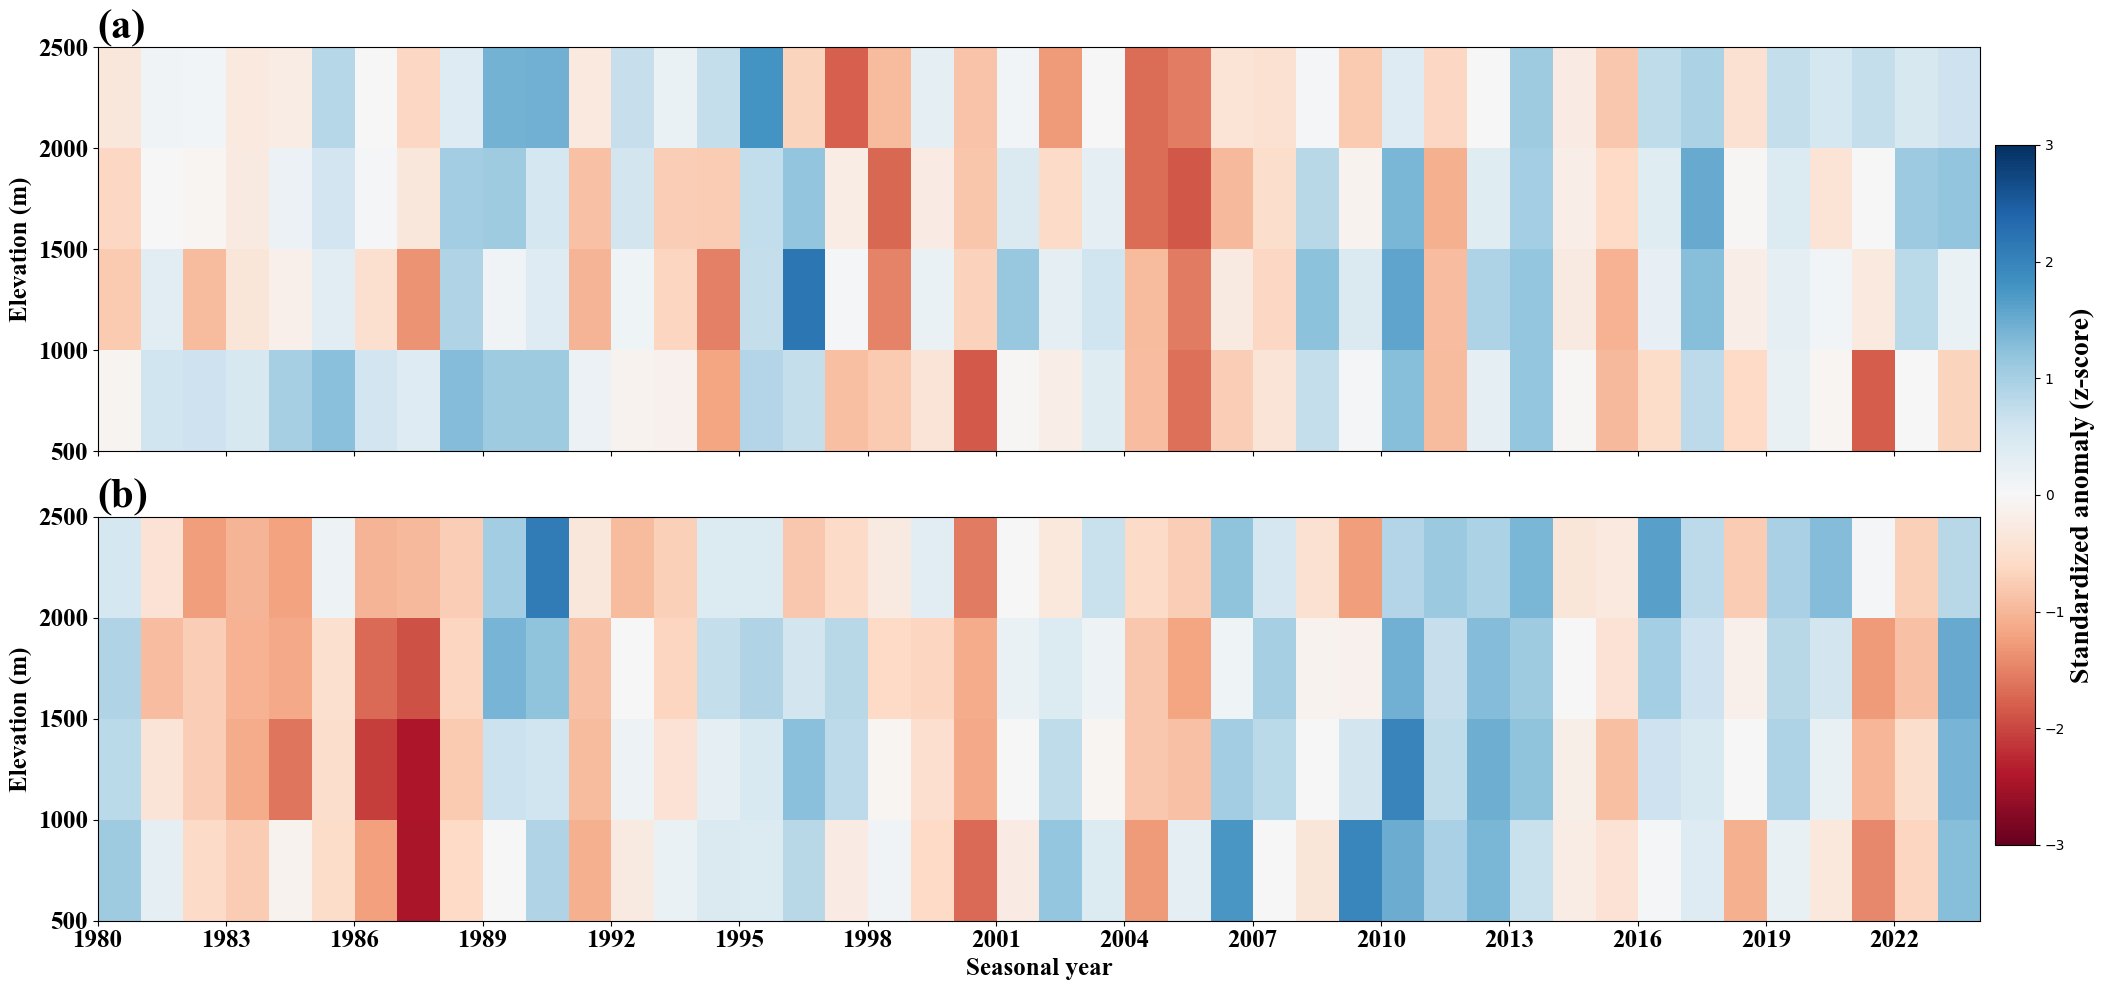

In [13]:
# Define elevation order explicitly
elev_order = ['2000_2500m','1500_2000m','1000_1500m','500_1000m']

# Pivot SPI

spi_mat = spi_8mo_avg.pivot_table(
    index="Elevation_Category",
    columns="Seasonal_Year",
    values="Avg_SPI_8mo",
    aggfunc="mean"
).reindex(elev_order)

# Pivot SWEI
swei_mat = swei_8mo_avg.pivot_table(
    index="Elevation_Category",
    columns="Seasonal_Year",
    values="Avg_SWEI_8mo",
    aggfunc="mean"
).reindex(elev_order)


# Keep only common years
common_years = sorted(set(spi_mat.columns).intersection(set(swei_mat.columns)))
spi_mat = spi_mat[common_years]
swei_mat = swei_mat[common_years]


# ---- Plot ----
fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)

vlim = 3  # same scale for both

im1 = axes[0].imshow(swei_mat.values, 
                     aspect="auto",
                     cmap="RdBu", 
                     vmin=-vlim, 
                     vmax=vlim,
                     extent=[0, swei_mat.shape[1], 500, 2500],
                     origin="upper")
axes[0].set_title("(a)", fontsize=30, fontweight='bold', family="Times New Roman", loc='left')
axes[0].set_ylabel("Elevation (m)", fontsize=18, fontweight='bold', family="Times New Roman")

# Tick positions at category boundaries (500..2500)
yticks = [500, 1000, 1500, 2000, 2500]
# Labels in meters at boundaries
ylabels = ['500', '1000', '1500', '2000', '2500']

axes[0].set_yticks(yticks)
axes[0].set_yticklabels(ylabels, fontsize=18, fontweight='bold', family="Times New Roman")

im2 = axes[1].imshow(spi_mat.values, 
                     aspect="auto",
                     cmap="RdBu", 
                     vmin=-vlim, 
                     vmax=vlim,
                     extent=[0, spi_mat.shape[1], 500, 2500],
                     origin="upper"
                     )
axes[1].set_title("(b)", fontsize=30, fontweight='bold', family="Times New Roman", loc='left')
axes[1].set_ylabel("Elevation (m)", fontsize=18, fontweight='bold', family="Times New Roman")
axes[1].set_xlabel("Seasonal year", fontsize=18, fontweight='bold', family="Times New Roman")
axes[1].set_yticks(yticks)
axes[1].set_yticklabels(ylabels, fontsize=18, fontweight='bold', family="Times New Roman")

# X-axis ticks (years)
years = common_years
step = max(1, len(years)//12)
axes[1].set_xticks(np.arange(len(years))[::step])
axes[1].set_xticklabels(years[::step], fontsize=18, fontweight='bold', family="Times New Roman")
axes[1].set_xlabel("Seasonal year", fontsize=18, fontweight='bold', family="Times New Roman")

# Shared colorbar on the right, outside the axes
# Place colorbar outside the main plot area
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label("Standardized anomaly (z-score)", fontsize=20, fontweight='bold', family="Times New Roman")

plt.tight_layout()
# save figure
out_file_heatmap = config['output_plots'] / f'SWEI_SPI_bow_basin_8month_heatmap.png'
fig.savefig(out_file_heatmap, dpi=1000, bbox_inches='tight')
plt.show()

In [14]:
# merge SWEI and SPI data for comparison
swei_spi_comparison = swei_8mo_avg.merge(
    spi_8mo_avg,
    on=['Elevation_Category', 'Seasonal_Year', 'month'],
    how='inner',
    suffixes=('_SWEI', '_SPI')
)
display(swei_spi_comparison.head())

,Elevation_Category,Seasonal_Year,month,Avg_SWEI_8mo,Avg_SPI_8mo
0,1000_1500m,1980,5,-0.778473,0.813369
1,1000_1500m,1981,5,0.320094,-0.395595
2,1000_1500m,1982,5,-0.942805,-0.728869
3,1000_1500m,1983,5,-0.356098,-1.105589
4,1000_1500m,1984,5,-0.147442,-1.615920


In [15]:
# calculate difference between SWEI and SPI
swei_spi_comparison['SPI_minus_SWEI'] = swei_spi_comparison['Avg_SPI_8mo'] - swei_spi_comparison['Avg_SWEI_8mo']

#save the comparison data to CSV
save_path = config['output_data'] / 'swei_spi_comparison.csv'
swei_spi_comparison.to_csv(save_path, index=False)
display(swei_spi_comparison.head())

,Elevation_Category,Seasonal_Year,month,Avg_SWEI_8mo,Avg_SPI_8mo,SPI_minus_SWEI
0,1000_1500m,1980,5,-0.778473,0.813369,1.591843
1,1000_1500m,1981,5,0.320094,-0.395595,-0.715689
2,1000_1500m,1982,5,-0.942805,-0.728869,0.213936
3,1000_1500m,1983,5,-0.356098,-1.105589,-0.749491
4,1000_1500m,1984,5,-0.147442,-1.615920,-1.468478


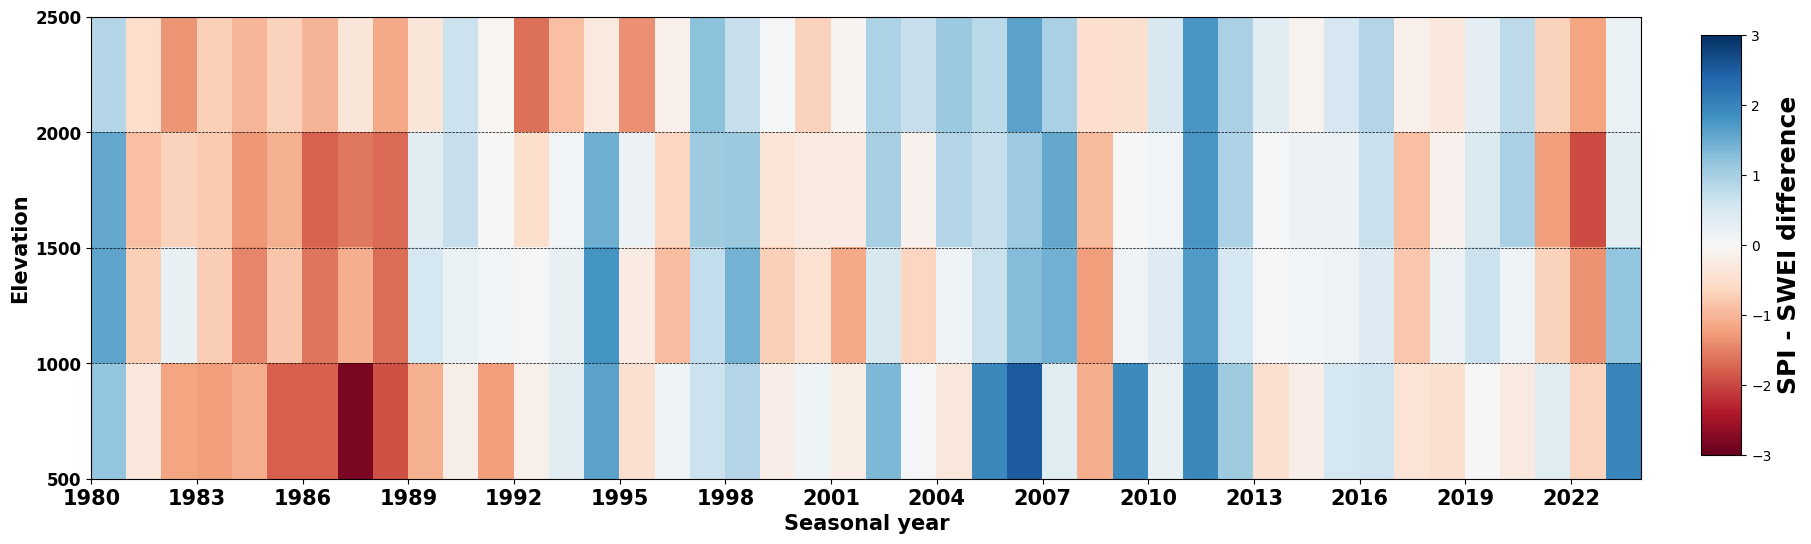

In [16]:
# plot heat map for the diffrence between SWEI and SPI

# Pivot SPI-SWEI
spi_swei_mat = swei_spi_comparison.pivot_table(
    index="Elevation_Category",
    columns="Seasonal_Year",
    values="SPI_minus_SWEI"
).reindex(elev_order)

# Single plot (reuse same axis for both references below)
fig, ax = plt.subplots(1, 1, figsize=(20, 6))
axes = np.array([ax, ax])  # axes[0] and axes[1] both point to the same Axes

# Years used for x-axis labelling
common_years = spi_swei_mat.columns.tolist()

vlim = 3 

im1 = axes[0].imshow(spi_swei_mat.values, aspect="auto",
                     cmap="RdBu", vmin=-vlim, vmax=vlim)
#axes[0].set_title("Difference between Seasonal SPI and SWEI (Oct–May)", fontsize=14)
axes[0].set_ylabel("Elevation", fontsize=15, fontweight='bold')
axes[0].set_yticks(np.arange(len(spi_swei_mat.index)))
axes[0].set_yticklabels(spi_swei_mat.index)

# Y-axis: numeric elevation ticks and dividing lines between categories
# Replot with explicit extent so that integer y positions are bin borders
n_elev = spi_swei_mat.shape[0]

# Older Matplotlib versions do not support `clear()` on ArtistList (axes[0].images),
# so we directly add a new image without attempting to clear the existing one.
im1 = axes[0].imshow(
    spi_swei_mat.values,
    aspect="auto",
    cmap="RdBu",
    vmin=-vlim,
    vmax=vlim,
    extent=[0, spi_swei_mat.shape[1], 500, 2500],
    origin="upper",
)

# Tick positions at category boundaries (500..2500)
yticks = [500, 1000, 1500, 2000, 2500]
# Labels in meters at boundaries
ylabels = ['500', '1000', '1500', '2000', '2500']

axes[0].set_yticks(yticks)
axes[0].set_yticklabels((ylabels), fontsize=12, fontweight='bold')

# Horizontal grid lines at each elevation boundary
axes[0].grid(axis='y', color='black', linestyle='--', linewidth=0.5)

# X-axis ticks (years)axes[1].set_xticks(np.arange(len(years))[::step]+0.5)  # +0.5 to center ticks between columns
years = common_years
step = max(1, len(years)//12)
axes[1].set_xticks(np.arange(len(years))[::step])
axes[1].set_xticklabels(years[::step], fontsize=15, fontweight='bold')
axes[1].set_xlabel("Seasonal year", fontsize=15, fontweight='bold')


years = common_years
step = max(1, len(years)//12)


# Shared colorbar on the right, outside the axes
# Place colorbar outside the main plot area
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label("SPI - SWEI difference", fontsize=18, fontweight='bold')
#plt.tight_layout()
# save figure
#out_file_heatmap_diff = config['SWEI_plots'] / f'SWEI_minus_SPI_bow_basin_8month_heatmap.png'
#fig.savefig(out_file_heatmap_diff, dpi=1000, bbox_inches='tight')
plt.show()

In [17]:
# load SD classification data
SD_years_data_path = config['SD_classification_all_years']
SD_years_data = pd.read_csv(SD_years_data_path)
display(SD_years_data.head())

# load SD types data
SD_types_path = config['SD_types']
SD_types_data = pd.read_csv(SD_types_path)
display(SD_types_data.head())

# load drought years data
drought_years_path = config['drought_years']
drought_years_data = pd.read_csv(drought_years_path)
display(drought_years_data.head())


,Elevation_Category,Seasonal_Year,Avg_SWE_P_ratio,Avg_Cum_P_anomaly,is_swei_drought,cluster_name,cluster
0,1000_1500m,1980,0.017906,43.219919,True,Warm,0.0
1,1000_1500m,1981,0.043095,-27.761347,False,Normal,-1.0
2,1000_1500m,1982,0.027718,-41.996265,True,Warm & Dry,2.0
3,1000_1500m,1983,0.037195,-60.840708,False,Normal,-1.0
4,1000_1500m,1984,0.054673,-81.794527,False,Normal,-1.0


,Elevation_Category,dry,dry&warm,warm,Drought_Years,unmatched,missing_from_classification_data
0,500_1000m,"[2004, 2018]","[1997, 1998, 2000, 2015, 2016, 2021]","[1994, 2005, 2006, 2011, 2023]","[1994, 1997, 1998, 2000, 2004, 2005, 2006, 201...",[],[]
1,1000_1500m,"[1987, 2000]","[1982, 1991, 1993, 2004, 2005, 2015]","[1980, 1994, 1998, 2007, 2011]","[1980, 1982, 1987, 1991, 1993, 1994, 1998, 200...",[],[]
2,1500_2000m,"[1991, 1993, 2000, 2015]","[1998, 2004, 2005, 2006]","[1980, 1994, 2002, 2007, 2011]","[1980, 1991, 1993, 1994, 1998, 2000, 2002, 200...",[],[]
3,2000_2500m,"[1987, 2000, 2009]","[1996, 1998, 2004, 2005, 2015]","[1997, 2002, 2011]","[1987, 1996, 1997, 1998, 2000, 2002, 2004, 200...",[],[]


,Elevation_Category,Drought_Years
0,1000_1500m,"[1980, 1982, 1987, 1991, 1993, 1994, 1998, 200..."
1,1500_2000m,"[1980, 1991, 1993, 1994, 1998, 2000, 2002, 200..."
2,2000_2500m,"[1987, 1996, 1997, 1998, 2000, 2002, 2004, 200..."
3,500_1000m,"[1994, 1997, 1998, 2000, 2004, 2005, 2006, 201..."


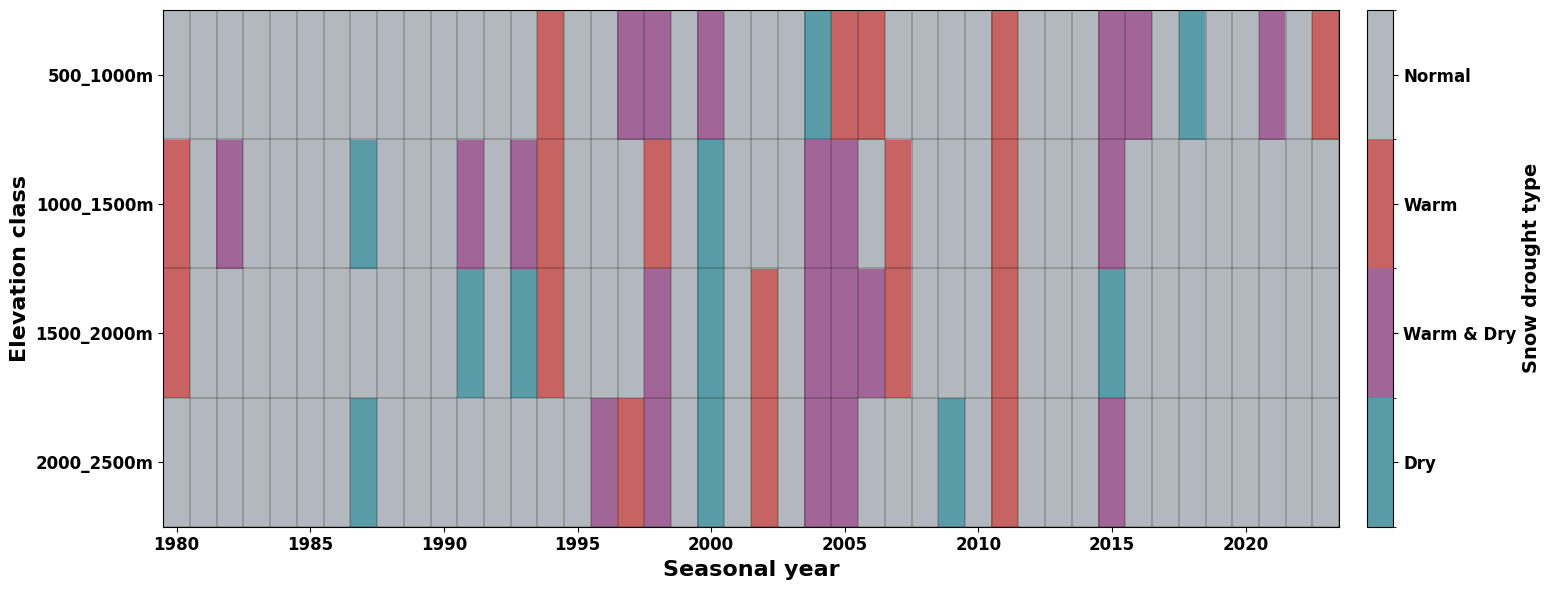

In [18]:
# Heatmap of final snow drought classification.
# Normal = years that are not SWEI drought years.
drought_type_colors = {
    "Dry": "#599CA8",
    "Warm & Dry": "#A16597",
    "Warm": "#C76363",
    "Normal": "#B2B8BD",
}

class_to_value = {
    "Dry": 1,
    "Warm & Dry": 2,
    "Warm": 3,
    "Normal": 4,
}

plot_df = SD_years_data.copy()
plot_df["type_value"] = plot_df["cluster_name"].map(class_to_value)

all_years = sorted(plot_df["Seasonal_Year"].dropna().astype(int).unique())
elevations_ordered = [e for e in elev_order if e in plot_df["Elevation_Category"].unique()]

heatmap_data = np.full((len(elevations_ordered), len(all_years)), np.nan)
for i, elev in enumerate(elevations_ordered):
    elev_df = plot_df[plot_df["Elevation_Category"] == elev]
    year_to_value = dict(zip(elev_df["Seasonal_Year"].astype(int), elev_df["type_value"]))
    for j, year in enumerate(all_years):
        heatmap_data[i, j] = year_to_value.get(year, np.nan)

cmap = ListedColormap([
    drought_type_colors["Dry"],
    drought_type_colors["Warm & Dry"],
    drought_type_colors["Warm"],
    drought_type_colors["Normal"],
])
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_data, aspect="auto", cmap=cmap, norm=norm)

# X-axis ticks every 5 years
all_years_arr = np.array(all_years)
tick_years = np.arange(all_years_arr.min(), all_years_arr.max() + 1, 5)
tick_pos = [np.where(all_years_arr == y)[0][0] for y in tick_years if y in all_years_arr]
ax.set_xticks(tick_pos)
ax.set_xticklabels([str(y) for y in tick_years if y in all_years_arr], fontsize=12, fontweight="bold")

ax.set_yticks(np.arange(len(elevations_ordered)))
ax.set_yticklabels(elevations_ordered, fontsize=12, fontweight="bold")
ax.invert_yaxis()

ax.set_xlabel("Seasonal year", fontsize=16, fontweight="bold")
ax.set_ylabel("Elevation class", fontsize=16, fontweight="bold")

# Grid lines between cells
ax.set_xticks(np.arange(-0.5, len(all_years), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(elevations_ordered), 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=0.25)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, ticks=[1, 2, 3, 4], pad=0.02)
cbar.set_ticklabels(["Dry", "Warm & Dry", "Warm", "Normal"], fontsize=12, fontweight="bold")
cbar.set_label("Snow drought type", fontsize=14, fontweight="bold")

plt.tight_layout()
# plt.savefig(config['output_plots'] / 'Snow_Drought_Classification_Heatmap_clean.png', dpi=1000, bbox_inches='tight')
plt.show()

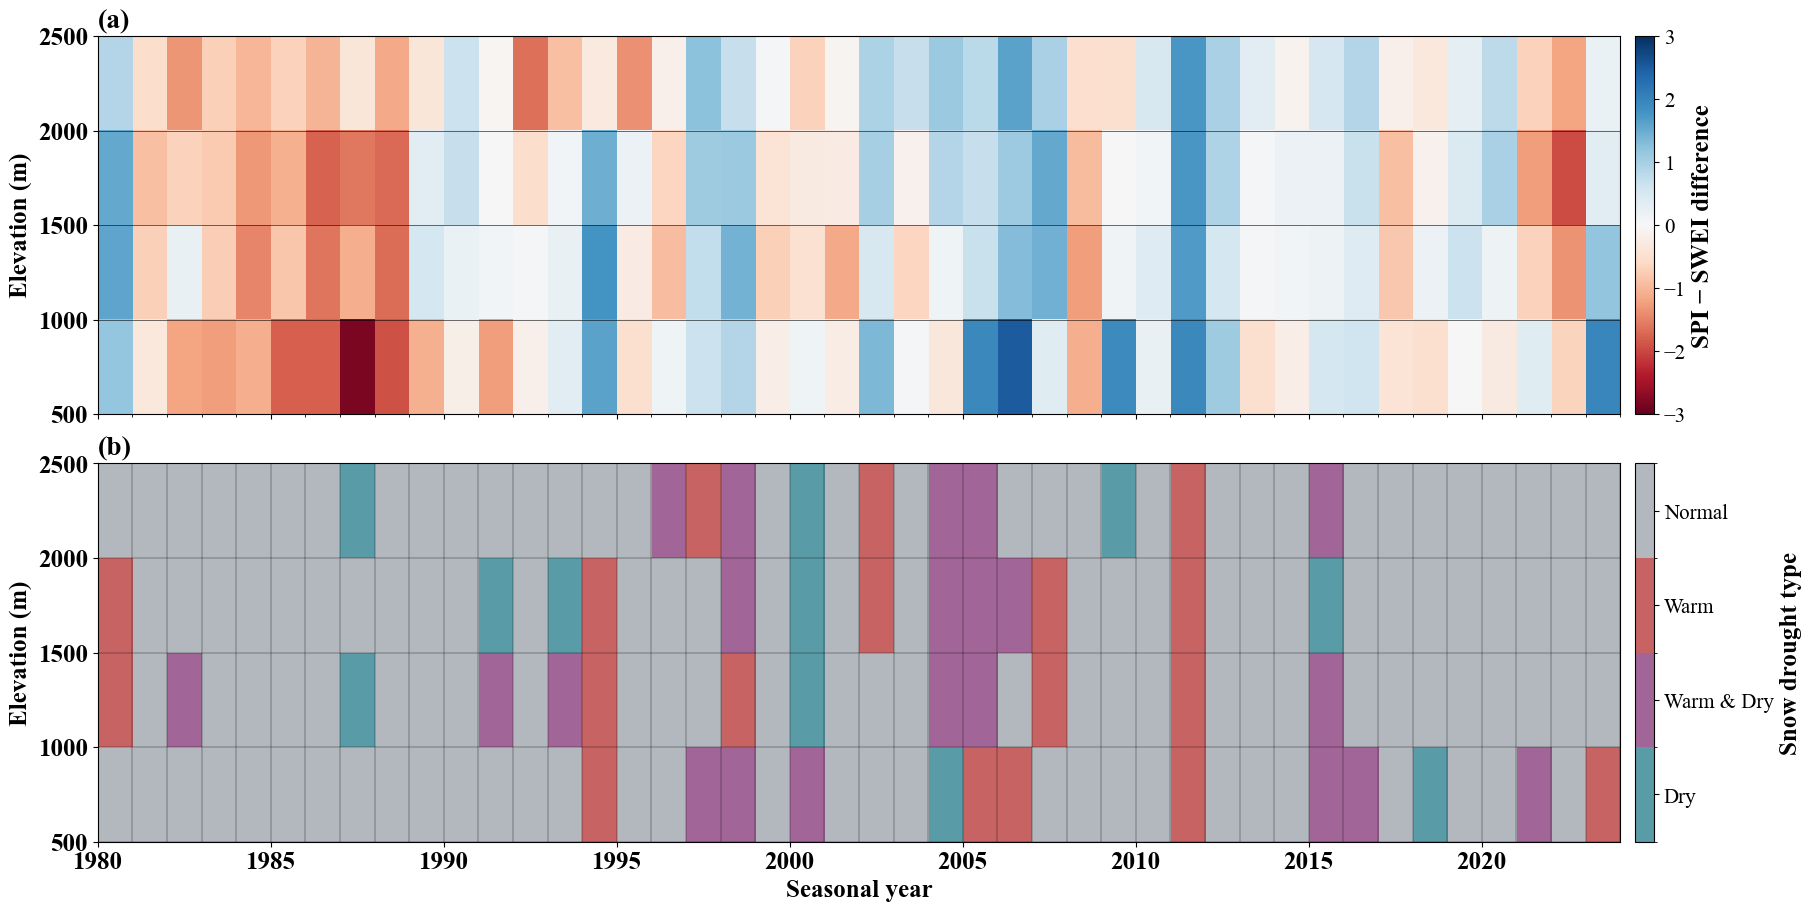

In [19]:
# ---------------------------------------------------------
# 1. Common settings
# ---------------------------------------------------------

# Elevation bands must be arranged from lowest to highest
preferred_elevation_order = [
    "500_1000m",
    "1000_1500m",
    "1500_2000m",
    "2000_2500m",
]

available_elevations = set(SD_years_data["Elevation_Category"].unique()) | set(
    swei_spi_comparison["Elevation_Category"].unique()
)

elevations_ordered = [
    elev for elev in preferred_elevation_order
    if elev in available_elevations
]

n_years = len(common_years)

x_extent = [ n_years ]
y_extent = [500, 2500]

yticks = [500, 1000, 1500, 2000, 2500]
ylabels = ["500", "1000", "1500", "2000", "2500"]

# Use the union of years from both datasets
common_years = sorted(
    set(SD_years_data["Seasonal_Year"].dropna().astype(int))
    | set(swei_spi_comparison["Seasonal_Year"].dropna().astype(int))
)

# ---------------------------------------------------------
# 2. Prepare SPI - SWEI matrix
# ---------------------------------------------------------

spi_swei_mat = (
    swei_spi_comparison
    .pivot_table(
        index="Elevation_Category",
        columns="Seasonal_Year",
        values="SPI_minus_SWEI",
        aggfunc="mean"
    )
    .reindex(
        index=elevations_ordered,
        columns=common_years
    )
)

# ---------------------------------------------------------
# 3. Prepare snow drought classification matrix
# ---------------------------------------------------------

drought_type_colors = {
    "Dry": "#599CA8",
    "Warm & Dry": "#A16597",
    "Warm": "#C76363",
    "Normal": "#B2B8BD",
}

class_to_value = {
    "Dry": 1,
    "Warm & Dry": 2,
    "Warm": 3,
    "Normal": 4,
}

classification_df = SD_years_data.copy()

classification_df["type_value"] = (
    classification_df["cluster_name"]
    .map(class_to_value)
)

classification_mat = (
    classification_df
    .pivot_table(
        index="Elevation_Category",
        columns="Seasonal_Year",
        values="type_value",
        aggfunc="first"
    )
    .reindex(
        index=elevations_ordered,
        columns=common_years
    )
)

classification_cmap = ListedColormap([
    drought_type_colors["Dry"],
    drought_type_colors["Warm & Dry"],
    drought_type_colors["Warm"],
    drought_type_colors["Normal"],
])

classification_norm = BoundaryNorm(
    [0.5, 1.5, 2.5, 3.5, 4.5],
    classification_cmap.N
)

# ---------------------------------------------------------
# 4. Create the combined figure
# ---------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(18, 9),
    sharex=True,
    constrained_layout=True
)

ax1, ax2 = axes

# ---------------------------------------------------------
# Panel a: SPI - SWEI difference
# ---------------------------------------------------------

vlim = 3

im1 = ax1.imshow(
    spi_swei_mat.values,
    aspect="auto",
    cmap="RdBu",
    vmin=-vlim,
    vmax=vlim,
    interpolation="none",
    origin="lower",
    extent=[0, n_years, y_extent[0], y_extent[1]]
)

ax1.set_title("(a)", fontsize=20, fontweight="bold", family="Times New Roman", loc="left")

ax1.set_ylabel(
    "Elevation (m)",
    fontsize=18,
    fontweight="bold",
    family="Times New Roman"
)

ax1.set_yticks(yticks)
ax1.set_yticklabels(
    ylabels,
    fontsize=18,
    fontweight="bold",
    family="Times New Roman"
)

# Lines at elevation-band boundaries
ax1.grid(
    axis="y",
    which="major",
    color="black",
    linestyle="-",
    linewidth=0.4
)
ax1.tick_params(
    which="minor",
    left=False
)

cbar1 = fig.colorbar(
    im1,
    ax=ax1,
    pad=0.01,
    fraction=0.025
)

cbar1.set_label(
    "SPI − SWEI difference",
    fontsize=18,
    fontweight="bold",
    family="Times New Roman"
)

cbar1.ax.tick_params(labelsize=15)
for lbl in cbar1.ax.get_yticklabels():
    lbl.set_fontfamily("Times New Roman")

# ---------------------------------------------------------
# Panel b: Snow drought classification
# ---------------------------------------------------------

im2 = ax2.imshow(
    classification_mat.values,
    aspect="auto",
    cmap=classification_cmap,
    norm=classification_norm,
    interpolation="none",
    origin="lower",
    extent=[0, n_years, y_extent[0], y_extent[1]]
)

ax2.set_title("(b)", fontsize=20, fontweight="bold", family="Times New Roman", loc="left")

ax2.set_ylabel(
    "Elevation (m)",
    fontsize=18,
    fontweight="bold",
    family="Times New Roman"
)

ax2.set_yticks(yticks)
ax2.set_yticklabels(
    ylabels,
    fontsize=18,
    fontweight="bold",
    family="Times New Roman"
)

# Horizontal elevation boundaries
ax2.grid(
    axis="y",
    which="major",
    color="black",
    linestyle="-",
    linewidth=0.4
)

# Grid lines between cells
ax2.set_xticks(np.arange(0, n_years + 1, 1), minor=True)
ax2.grid(which="both", color="black", linestyle="-", linewidth=0.25)
ax2.tick_params(which="minor", bottom=False, left=False)

cbar2 = fig.colorbar(
    im2,
    ax=ax2,
    ticks=[1, 2, 3, 4],
    pad=0.01,
    fraction=0.025
)

cbar2.set_ticklabels([
    "Dry",
    "Warm & Dry",
    "Warm",
    "Normal"
])

cbar2.set_label(
    "Snow drought type",
    fontsize=18,
    fontweight="bold",
    family="Times New Roman"
)

cbar2.ax.tick_params(labelsize=15)
for lbl in cbar2.ax.get_yticklabels():
    lbl.set_fontfamily("Times New Roman")

# ---------------------------------------------------------
# 5. Common x-axis
# ---------------------------------------------------------

common_years_array = np.array(common_years)

tick_years = np.arange(
    common_years_array.min(),
    common_years_array.max() + 1,
    5
)

tick_positions = [
    np.where(common_years_array == year)[0][0]
    for year in tick_years
    if year in common_years_array
]

tick_labels = [
    str(year)
    for year in tick_years
    if year in common_years_array
]

ax2.set_xticks(tick_positions)
ax2.set_xticklabels(
    tick_labels,
    fontsize=18,
    fontweight="bold",
    family="Times New Roman"
)

ax2.set_xlabel(
    "Seasonal year",
    fontsize=18,
    fontweight="bold",
    family="Times New Roman"
)

# Hide x labels on the upper panel
ax1.tick_params(
    axis="x",
    labelbottom=False
)

# ---------------------------------------------------------
# 6. Save and display
# ---------------------------------------------------------

output_file = (config["output_plots"] / "SPI_SWEI_and_SD_classification_combined.png")

fig.savefig(output_file, dpi=1000, bbox_inches="tight" )

plt.show()

# Peak SWE

In [20]:
# load peak SWE data
peak_swe_data_path = config['peak_swe_data']
peak_swe_data = pd.read_csv(peak_swe_data_path)
display(peak_swe_data.head())

,station_id,Seasonal_Year,Original_Peak_SWE,Original_Peak_SWE_Date,GapFilled_Peak_SWE,GapFilled_Peak_SWE_Date,Elevation_Category,station_name,lat,lon
0,ALE-05BA801,1980.0,244.0,1981-04-01,244.0,1981-04-01,1500_2000m,BOW RIVER,51.423084,-116.18369
1,ALE-05BA801,1981.0,234.0,1982-03-31,234.0,1982-03-31,1500_2000m,BOW RIVER,51.423084,-116.18369
2,ALE-05BA801,1982.0,206.0,1983-03-28,206.0,1983-03-28,1500_2000m,BOW RIVER,51.423084,-116.18369
3,ALE-05BA801,1983.0,142.0,1984-03-01,142.0,1984-03-01,1500_2000m,BOW RIVER,51.423084,-116.18369
4,ALE-05BA801,1984.0,175.0,1985-03-28,175.0,1985-03-28,1500_2000m,BOW RIVER,51.423084,-116.18369


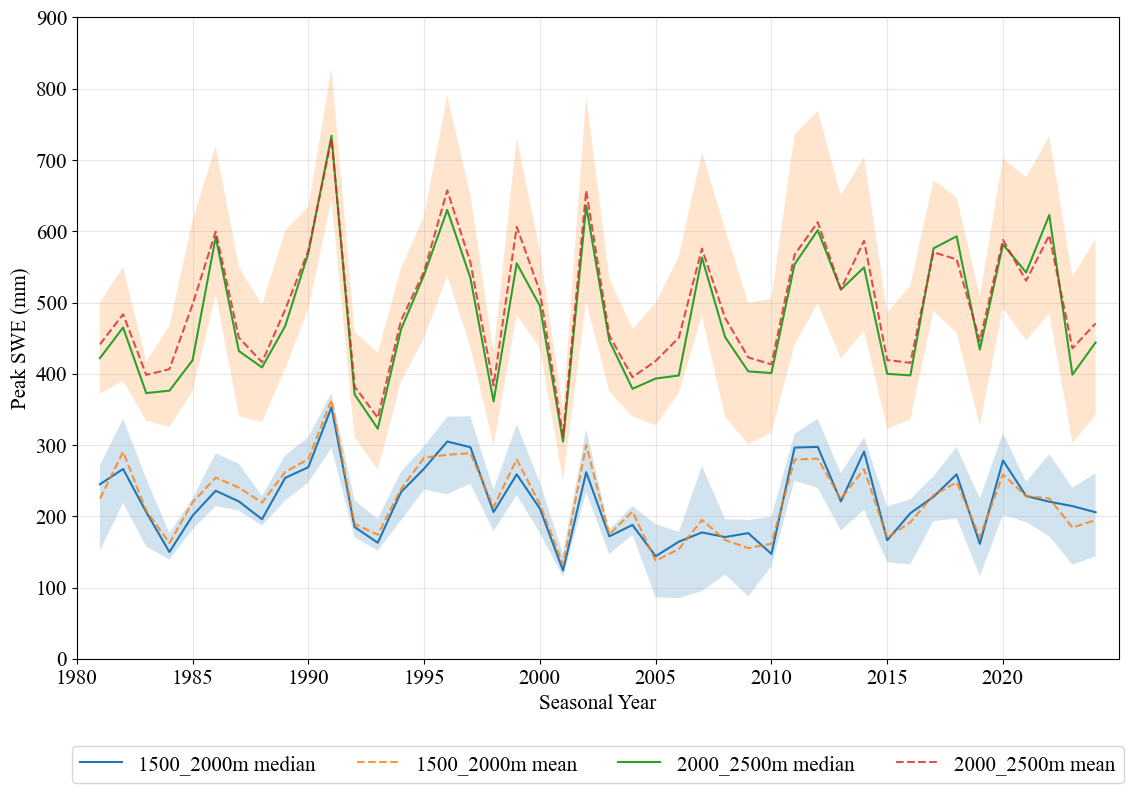

In [21]:
# ensure category order
elev_order = ['1500_2000m', '2000_2500m']
peak_swe_data['Elevation_Category'] = pd.Categorical(
    peak_swe_data['Elevation_Category'],
    categories=elev_order,
    ordered=True
)

# summarize by year and elevation
summary = (
    peak_swe_data
    .dropna(subset=['Elevation_Category', 'GapFilled_Peak_SWE'])
    .groupby(['Seasonal_Year', 'Elevation_Category'], observed=True)['GapFilled_Peak_SWE']
    .agg(
        mean='mean',
        median='median',
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# plot
fig, ax = plt.subplots(figsize=(12, 8))

for elev in elev_order:
    sub = summary[summary['Elevation_Category'] == elev].sort_values('Seasonal_Year')
    ax.plot(sub['Seasonal_Year'] + 1, sub['median'], label=f'{elev} median')
    ax.fill_between(sub['Seasonal_Year']+1, sub['q25'], sub['q75'], alpha=0.2)
    ax.plot(sub['Seasonal_Year']+1, sub['mean'], linestyle='--', alpha=0.8, label=f'{elev} mean')

#ax.set_title('Seasonal Peak SWE by Elevation Band - Gap-filled CanSWE Data')
ax.set_xlabel('Seasonal Year', fontsize=15, family="Times New Roman")
ax.set_ylabel('Peak SWE (mm)', fontsize=15, family="Times New Roman")
ax.legend(
    prop={'family': 'Times New Roman', 'size': 15},
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=True
)
years = sorted(summary['Seasonal_Year'].unique())
ax.set_xticks(years[::5])
ax.tick_params(axis='x', labelsize=15)
for label in ax.get_xticklabels():
    label.set_family("Times New Roman")
ax.set_xlim(1980, 2025)
ax.tick_params(axis='y', labelsize=15)
for label in ax.get_yticklabels():
    label.set_family("Times New Roman")
ax.set_ylim(0, 900)
ax.grid(True, alpha=0.3)

plt.tight_layout()
savefig = config['output_plots'] / 'bow_peak_swe_by_elevation_gapfilled.png'
plt.savefig(savefig, dpi=1000)
plt.show()

# Weekly SWE

In [40]:

def assign_common_plot_time(
    date_series: pd.Series,
    common_start_year: int = 2023,
    water_year_start_month: int = 10
) -> pd.Series:
    """
    Map dates from different winter seasons onto a common plotting period.

    For example, with common_start_year=2023 and water_year_start_month=10 (October):
        November-December -> 2023
        January-April     -> 2024
    """
    dates = pd.to_datetime(date_series)

    return dates.apply(
        lambda date: date.replace(
            year=(
                common_start_year
                if date.month >= water_year_start_month
                else common_start_year + 1
            )
        )
    )

def plot_weekly_swei_season_comparison(
    current_season_df,
    comparison_season_df,
    current_label,
    comparison_label,
    save_path=None,
    time_col="time",
    station_col="station_name",
    swei_col="SWEI",
    common_start_year=2025,
    water_year_start_month=10,
    figsize=(12, 8),
    dpi=1000
):
    """
    Plot the current-season basin mean and station min-max range,
    together with the comparison-season basin mean.
    """

    # ---------------------------------------------------------
    # Check columns
    # ---------------------------------------------------------

    current_required = {time_col, station_col, swei_col}
    comparison_required = {time_col, swei_col}

    missing_current = current_required - set(current_season_df.columns)
    missing_comparison = comparison_required - set(
        comparison_season_df.columns
    )

    if missing_current:
        raise KeyError(
            f"Current season is missing columns: "
            f"{sorted(missing_current)}"
        )

    if missing_comparison:
        raise KeyError(
            f"Comparison season is missing columns: "
            f"{sorted(missing_comparison)}"
        )

    # ---------------------------------------------------------
    # Prepare safe copies
    # ---------------------------------------------------------

    current_plot = current_season_df.copy()
    comparison_plot = comparison_season_df.copy()

    current_plot[time_col] = pd.to_datetime(
        current_plot[time_col],
        errors="coerce"
    )

    comparison_plot[time_col] = pd.to_datetime(
        comparison_plot[time_col],
        errors="coerce"
    )

    current_plot[swei_col] = pd.to_numeric(
        current_plot[swei_col],
        errors="coerce"
    )

    comparison_plot[swei_col] = pd.to_numeric(
        comparison_plot[swei_col],
        errors="coerce"
    )

    current_plot = current_plot.dropna(
        subset=[time_col, station_col, swei_col]
    )

    comparison_plot = comparison_plot.dropna(
        subset=[time_col, swei_col]
    )

    # ---------------------------------------------------------
    # Assign common plotting dates
    # ---------------------------------------------------------

    current_plot["plot_time"] = assign_common_plot_time(
        current_plot[time_col],
        common_start_year=common_start_year,
        water_year_start_month=water_year_start_month
    )

    comparison_plot["plot_time"] = assign_common_plot_time(
        comparison_plot[time_col],
        common_start_year=common_start_year,
        water_year_start_month=water_year_start_month
    )

    # ---------------------------------------------------------
    # Calculate current-season station statistics
    # ---------------------------------------------------------

    current_stats = (
        current_plot
        .groupby("plot_time")[swei_col]
        .agg(
            basin_mean="mean",
            station_min="min",
            station_max="max",
            station_count="count"
        )
        .sort_index()
    )

    # Comparison-season basin mean
    comparison_mean = (
        comparison_plot
        .groupby("plot_time")[swei_col]
        .mean()
        .sort_index()
    )

    # ---------------------------------------------------------
    # Create plot
    # ---------------------------------------------------------

    fig, ax = plt.subplots(figsize=figsize)

    # Background severity bands first, so data remain visible
    ax.axhspan(-2.5, -1.6, color="red", alpha=0.10)
    ax.axhspan(-1.6, -0.5, color="orange", alpha=0.10)
    ax.axhspan(-0.5, 0.5, color="grey", alpha=0.05)
    ax.axhspan(0.5, 1.6, color="blue", alpha=0.08)
    ax.axhspan(1.6, 2.5, color="navy", alpha=0.15)

    # ---------------------------------------------------------
    # Current-season min-max station range
    # ---------------------------------------------------------

    ax.fill_between(
        current_stats.index,
        current_stats["station_min"],
        current_stats["station_max"],
        color="black",
        alpha=0.18,
        label=f"Station Range {current_label}",
        zorder=2
    )

    # Current-season basin mean
    ax.plot(
        current_stats.index,
        current_stats["basin_mean"],
        color="black",
        linewidth=2.8,
        linestyle="-",
        marker="o",
        markersize=4,
        label=f"Basin Mean {current_label}",
        zorder=4
    )

    # Comparison-season basin mean
    ax.plot(
        comparison_mean.index,
        comparison_mean.values,
        color="navy",
        linewidth=2.5,
        linestyle="--",
        label=f"Basin Mean {comparison_label}",
        zorder=4
    )

    # ---------------------------------------------------------
    # Thresholds
    # ---------------------------------------------------------

    ax.axhline(
        -0.5,
        color="red",
        linestyle="--",
        linewidth=1,
        label="Drought Threshold",
        zorder=3
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
        label="Zero Threshold",
        zorder=3
    )

    ax.axhline(
        0.5,
        color="blue",
        linestyle="--",
        linewidth=1,
        label="Wet Threshold",
        zorder=3
    )

    # ---------------------------------------------------------
    # Axis formatting
    # ---------------------------------------------------------

    ax.set_xlabel(
        "Month",
        fontsize=15,
        fontweight="bold",
        family="Times New Roman"
    )

    ax.set_ylabel(
        "SWEI",
        fontsize=15,
        fontweight="bold",
        family="Times New Roman"
    )

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    ax.set_xlim(
        pd.Timestamp(f"{common_start_year}-10-01"),
        pd.Timestamp(f"{common_start_year + 1}-05-01")
    )

    ax.set_ylim(-2.5, 2.5)

    ax.tick_params(
        axis="both",
        labelsize=15
    )

    for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
        tick_label.set_fontfamily("Times New Roman")

    ax.grid(
        True,
        linestyle="--",
        alpha=0.3,
        zorder=1
    )

    legend_font = FontProperties(
        family="Times New Roman",
        size=15
    )

    ax.legend(
        bbox_to_anchor=(0.5, -0.12),
        loc="upper center",
        ncol=3,
        prop=legend_font,
        frameon=True
    )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()

    return (
        fig,
        ax,
        current_stats,
        comparison_mean,
        current_plot,
        comparison_plot
    )

In [23]:
#load bow_weely_swei_data_path = config['bow_weekly_swei_data']
bow_weekly_swei_data_path = config["weekly_SWEI"]
bow_weekly_swei_data = pd.read_csv(bow_weekly_swei_data_path)
display(bow_weekly_swei_data.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name
0,ALE-05BA801,1981-02-01,201.0,1980,18,201.0,0.889273,1.222673,BOW RIVER
1,ALE-05BA801,1981-03-01,234.0,1980,22,234.0,0.852405,1.046802,BOW RIVER
2,ALE-05BA801,1981-04-05,244.0,1980,27,244.0,0.681159,0.470943,BOW RIVER
3,ALE-05BA801,1982-01-31,130.0,1981,18,130.0,0.305363,-0.509036,BOW RIVER
4,ALE-05BA801,1982-02-28,206.0,1981,22,206.0,0.645108,0.372146,BOW RIVER


In [24]:
# add column Elevation_category by comparing station_id in peak_swe_data
bow_weekly_swei_data['Elevation_Category'] = bow_weekly_swei_data['station_id'].map(
    peak_swe_data.drop_duplicates(subset=['station_id']).set_index('station_id')['Elevation_Category']
)
display(bow_weekly_swei_data.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name,Elevation_Category
0,ALE-05BA801,1981-02-01,201.0,1980,18,201.0,0.889273,1.222673,BOW RIVER,1500_2000m
1,ALE-05BA801,1981-03-01,234.0,1980,22,234.0,0.852405,1.046802,BOW RIVER,1500_2000m
2,ALE-05BA801,1981-04-05,244.0,1980,27,244.0,0.681159,0.470943,BOW RIVER,1500_2000m
3,ALE-05BA801,1982-01-31,130.0,1981,18,130.0,0.305363,-0.509036,BOW RIVER,1500_2000m
4,ALE-05BA801,1982-02-28,206.0,1981,22,206.0,0.645108,0.372146,BOW RIVER,1500_2000m


In [25]:
# drop rows with Elevation_Category = 1500_2000m
bow_weekly_swei_data = bow_weekly_swei_data[bow_weekly_swei_data['Elevation_Category'] != '1500_2000m']
display(bow_weekly_swei_data.head())

,station_id,time,SWE_weekly,Seasonal_Year,season_week,SWE_1wk,Gringorten_p,SWEI,station_name,Elevation_Category
262,ALE-05BA806,1981-02-01,249.0,1980,18,249.0,0.852405,1.046802,MIRROR LAKE,2000_2500m
263,ALE-05BA806,1981-03-01,257.0,1980,22,257.0,0.543253,0.108631,MIRROR LAKE,2000_2500m
264,ALE-05BA806,1981-04-05,318.0,1980,27,318.0,0.590580,0.229036,MIRROR LAKE,2000_2500m
265,ALE-05BA806,1982-01-31,142.0,1981,18,142.0,0.147595,-1.046802,MIRROR LAKE,2000_2500m
266,ALE-05BA806,1982-02-28,213.0,1981,22,213.0,0.391869,-0.274452,MIRROR LAKE,2000_2500m


In [35]:
# number of unique stations in each elevation category
station_counts = bow_weekly_swei_data.groupby('Elevation_Category')['station_id'].nunique()
print("Number of unique stations in each elevation category:")
print(station_counts)

Number of unique stations in each elevation category:
Elevation_Category
1500_2000m     0
2000_2500m    33
Name: station_id, dtype: int64


C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_38072\760051900.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  station_counts = bow_weekly_swei_data.groupby('Elevation_Category')['station_id'].nunique()


Case study 1: 2023-2024 winter

In [26]:
# choose data for season_year2022 and 2021
season_2022_weekly = bow_weekly_swei_data[bow_weekly_swei_data['Seasonal_Year'] == 2022]
season_2021_weekly = bow_weekly_swei_data[bow_weekly_swei_data['Seasonal_Year'] == 2021]

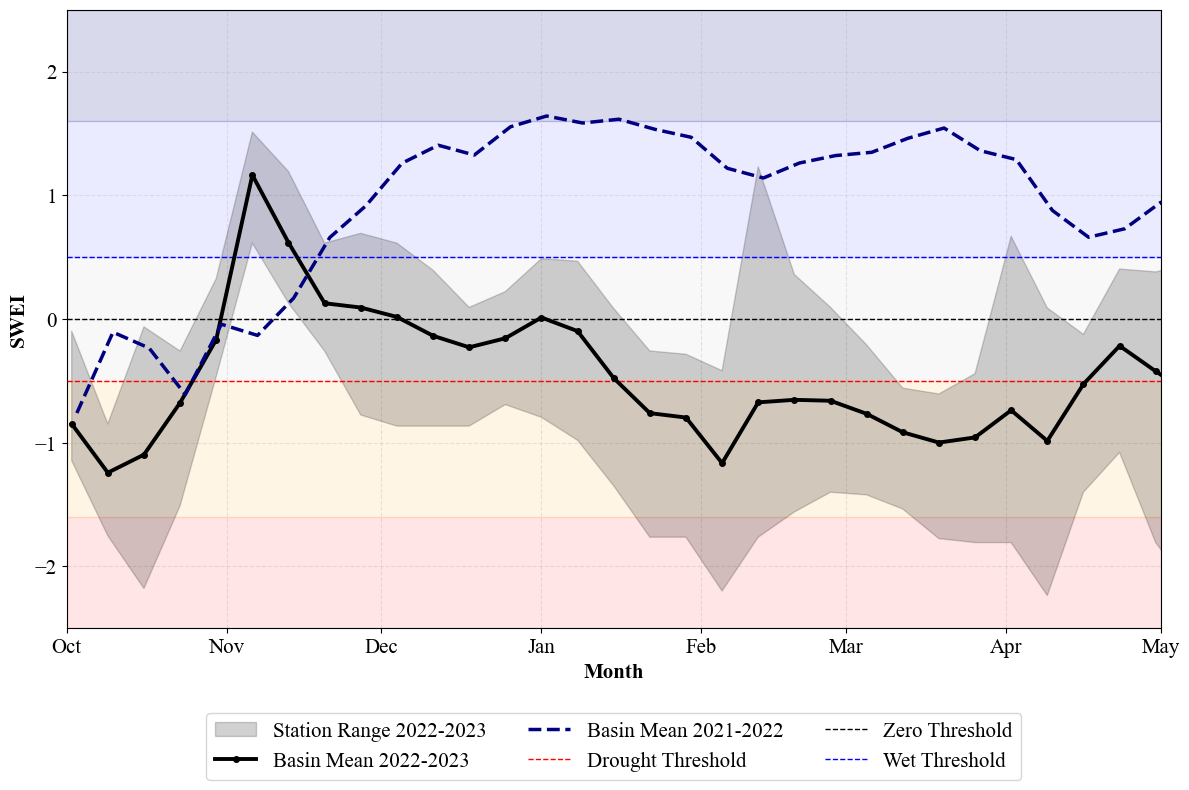

In [41]:
save_path = (
    config["output_plots"]
    / "bow_season_2022_weekly_swei_with_2021_mean.png"
)

(
    fig,
    ax,
    season_2011_stats,
    basin_mean_2010,
    season_2011_plot,
    season_2010_plot
) = plot_weekly_swei_season_comparison(
    current_season_df=season_2022_weekly,
    comparison_season_df=season_2021_weekly,
    current_label="2022-2023",
    comparison_label="2021-2022",
    save_path=save_path
)
  

Case study 2: 2000-2001

In [28]:
# choose data for season_year2022 and 2021
season_2000_weekly = bow_weekly_swei_data[bow_weekly_swei_data['Seasonal_Year'] == 2000]
season_1999_weekly = bow_weekly_swei_data[bow_weekly_swei_data['Seasonal_Year'] == 1999]

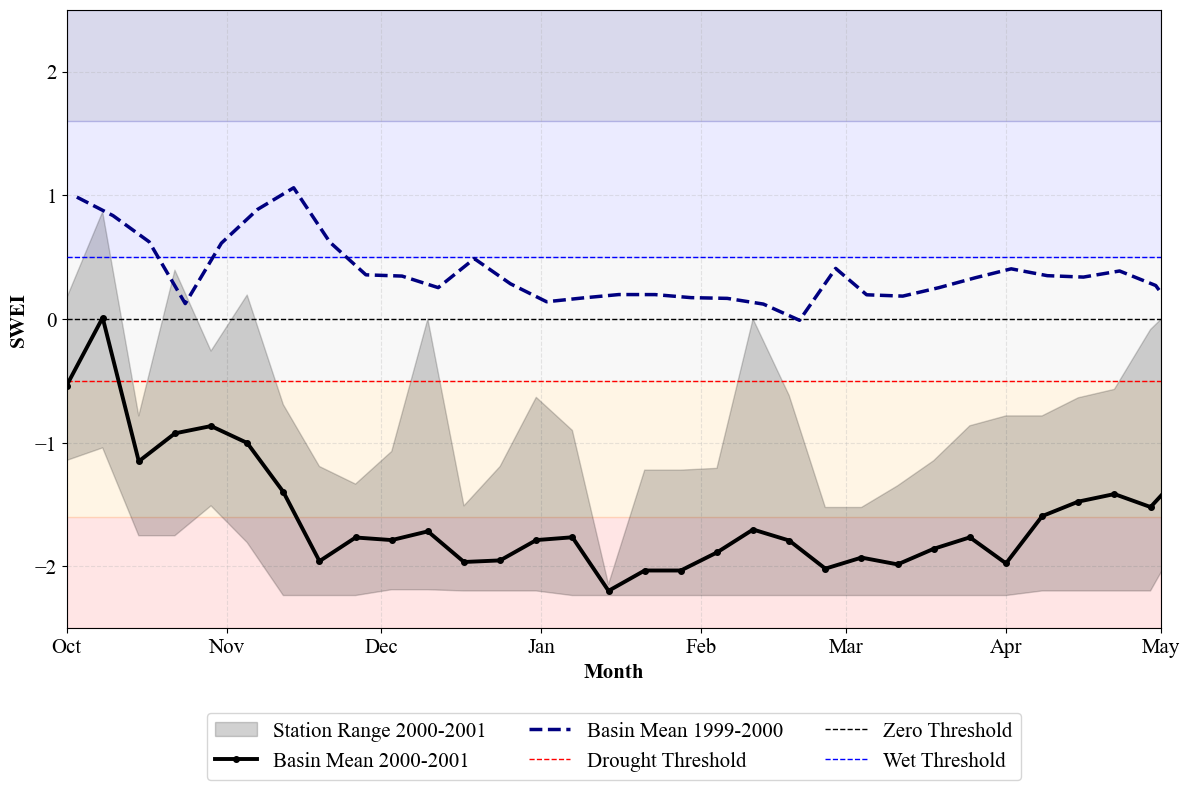

In [42]:
save_path = (
    config["output_plots"]
    / "bow_season_2000_weekly_swei_with_1999_mean.png"
)

(
    fig,
    ax,
    season_2000_stats,
    basin_mean_1999,
    season_2000_plot,
    season_1999_plot
) = plot_weekly_swei_season_comparison(
    current_season_df=season_2000_weekly,
    comparison_season_df=season_1999_weekly,
    current_label="2000-2001",
    comparison_label="1999-2000",
    save_path=save_path
)